In [1]:
pip install xgboost lightgbm scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pandas as pd
import numpy as np
import warnings
import gc
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("/kaggle/input/datasets/nguynnguynhehe/data43/data_43_temp.csv", skiprows=[1,2]) #trước mắt bỏ 2 dòng đầu cho dễ xử lí
# df = pd.read_csv("/kaggle/input/datasets/nguynnguynhehe/data43/Data_WindSpeed_43.csv")
print(f"temp_dataset: {df.shape}")

temp_dataset: (17526, 44)


---
# **Create Missing Data**

In [4]:
def generate_fixed_length_gaps(df_input, gap_days, num_gaps=10, seed=42, rows_per_day=8):
    """
    Tạo bộ dữ liệu missing với CÙNG MỘT độ dài gap cho tất cả các vị trí được chọn.
    Có tích hợp thuật toán chống đè (anti-overlap) để đảm bảo các gap không dính vào nhau.
    """
    df_temp = df_input.copy(deep=True)
    feature_columns = [col for col in df_temp.columns if col != "TimeVN"]
    
    # Đảm bảo format datetime để tìm đúng 1:00 AM
    ts = pd.to_datetime(df_temp['TimeVN'], format='mixed', dayfirst=True, errors='coerce')
    
    # Lấy ra vị trí (integer index) của các dòng có giờ = 1
    # Dùng np.where để lấy vị trí tuyệt đối, an toàn hơn loc khi thao tác
    daily_start_positions = np.where(ts.dt.hour == 1)[0].tolist()
    
    np.random.seed(seed)
    gap_rows = gap_days * rows_per_day
    
    # Dictionary lưu lại các index bị xóa để sau này tính RMSE, MAE
    missing_ground_truth = {col: [] for col in feature_columns}

    for col in feature_columns:
        col_idx = df_temp.columns.get_loc(col)
        
        # Chỉ giữ lại các vị trí bắt đầu mà khi cộng thêm gap_rows không vượt quá chiều dài data
        valid_starts = [pos for pos in daily_start_positions if pos + gap_rows <= len(df_temp)]
        
        available_starts = valid_starts.copy()
        
        for _ in range(num_gaps):
            if not available_starts:
                print(f"Cảnh báo: Không đủ khoảng trống để tạo đủ {num_gaps} gaps cho cột {col}")
                break
                
            # Chọn ngẫu nhiên 1 vị trí bắt đầu
            start_pos = np.random.choice(available_starts)
            end_pos = start_pos + gap_rows
            
            # Xóa dữ liệu (gán NaN)
            df_temp.iloc[start_pos:end_pos, col_idx] = np.nan
            
            # Lưu lại vị trí đã đục lỗ
            missing_ground_truth[col].extend(list(range(start_pos, end_pos)))
            
            # --- CƠ CHẾ CHỐNG ĐÈ (ANTI-OVERLAP) ---
            # Xóa bỏ các vị trí bắt đầu (start_pos) lân cận ra khỏi danh sách available_starts
            # Khoảng cách tối thiểu giữa 2 điểm bắt đầu phải lớn hơn chiều dài của gap
            available_starts = [pos for pos in available_starts if abs(pos - start_pos) > gap_rows]

    return df_temp, missing_ground_truth

# ================= TẠO 4 BỘ DATASET ĐỘC LẬP =================

# Giả sử 'df' là dataframe gốc của bạn
gap_scenarios = [1, 3, 5, 7]
missing_datasets = {}       # Chứa 4 dataframe đã bị đục lỗ
ground_truth_indices = {}   # Chứa vị trí các lỗ hổng để tính sai số sau này

for days in gap_scenarios:
    print(f"Đang tạo dataset cho kịch bản missing {days} ngày liên tục...")
    
    # Gọi hàm cho từng độ dài
    df_miss, truth_dict = generate_fixed_length_gaps(
        df_input=df, 
        gap_days=days, 
        num_gaps=10,   # Tùy chỉnh số lượng đoạn đứt gãy bạn muốn tạo
        seed=42,       # Giữ nguyên seed để kết quả random có thể tái lập được
        rows_per_day=8
    )
    
    # Lưu vào dictionary
    missing_datasets[f'gap_{days}d'] = df_miss
    ground_truth_indices[f'gap_{days}d'] = truth_dict
    
    total_nan = df_miss.isna().sum().sum()
    print(f"-> Hoàn tất! Tổng số NaN tạo ra: {total_nan}\n")

Đang tạo dataset cho kịch bản missing 1 ngày liên tục...
-> Hoàn tất! Tổng số NaN tạo ra: 3440

Đang tạo dataset cho kịch bản missing 3 ngày liên tục...
-> Hoàn tất! Tổng số NaN tạo ra: 10320

Đang tạo dataset cho kịch bản missing 5 ngày liên tục...
-> Hoàn tất! Tổng số NaN tạo ra: 17200

Đang tạo dataset cho kịch bản missing 7 ngày liên tục...
-> Hoàn tất! Tổng số NaN tạo ra: 24080



In [5]:
# import missingno as msno
# msno.matrix(df_missing)

In [6]:
def split_by_hierarchical_correlation(df, low_thresh, high_thresh, time_col='TimeVN'):
    # Tách dữ liệu số để tính toán
    df_numeric = df.select_dtypes(include=[np.number])
    
    # 1. Ensemble Correlation
    corr = (df_numeric.corr(method='pearson').abs() + 
            df_numeric.corr(method='spearman').abs()) / 2
    
    # 2. Distance Matrix & Linkage (Dùng cho Dendrogram)
    dist_matrix = 1 - corr.fillna(0)
    dist_vec = squareform(dist_matrix, checks=False)
    linkage_matrix = hierarchy.ward(dist_vec)
    
    # 3. Tính Degree Centrality (Mức độ quan trọng trung bình của biến trong mạng lưới)
    global_scores = (corr.sum() - 1) / (len(corr) - 1)
    
    # 4. Phân tách theo 3 ngưỡng
    # Low: score < 0.3
    low_cols = global_scores[global_scores < low_thresh].index.tolist()
    # Medium: 0.3 <= score < 0.8
    med_cols = global_scores[(global_scores >= low_thresh) & (global_scores < high_thresh)].index.tolist()
    # High: score >= 0.8
    high_cols = global_scores[global_scores >= high_thresh].index.tolist()
    
    # 5. Trả kết quả (Kèm theo cột thời gian nếu có)
    time_list = [time_col] if time_col in df.columns else []
    
    df_low = df[time_list + low_cols]
    df_med = df[time_list + med_cols]
    df_high = df[time_list + high_cols]
    
    return df_low, df_med, df_high, global_scores, linkage_matrix

🎯 Ngưỡng tự động được chọn: LOW < 0.742 | 0.742 <= MED < 0.764 | HIGH >= 0.764


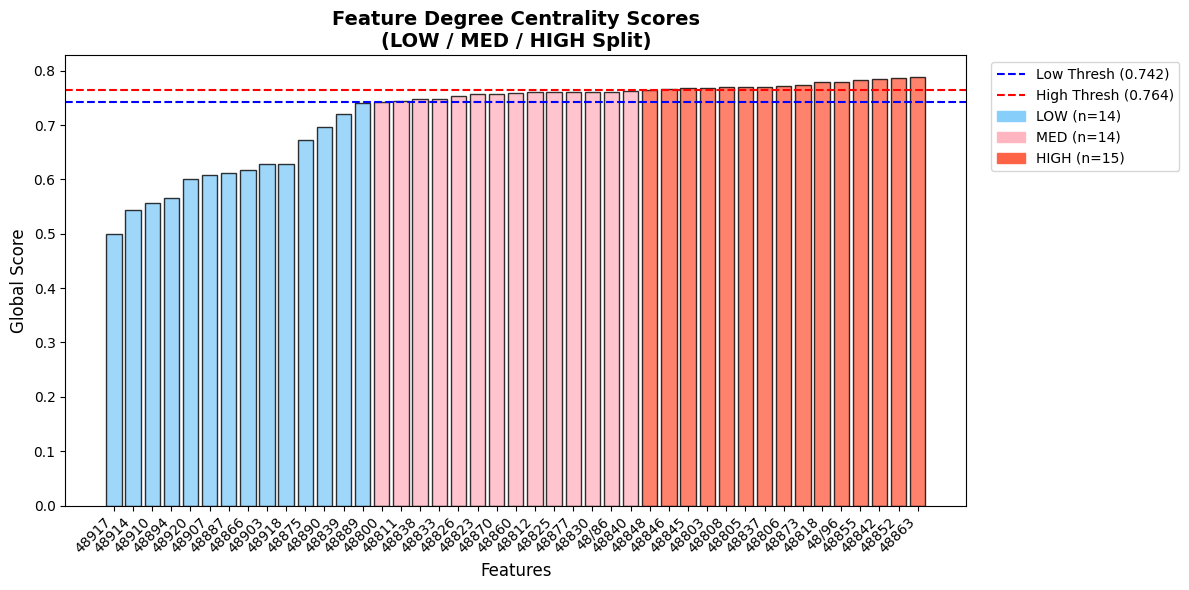

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_correlation_split(global_scores, low_thresh, high_thresh):
    """
    Vẽ biểu đồ Bar Chart phân loại LOW / MED / HIGH, kèm theo số lượng đếm.
    """
    # Sắp xếp điểm số tăng dần để biểu đồ nhìn mượt mà
    scores_sorted = global_scores.sort_values()
    features = scores_sorted.index
    values = scores_sorted.values

    # --- ĐẾM SỐ LƯỢNG CHO TỪNG NHÓM ---
    low_count = np.sum(values < low_thresh)
    med_count = np.sum((values >= low_thresh) & (values < high_thresh))
    high_count = np.sum(values >= high_thresh)

    # Xác định màu sắc
    colors = []
    for val in values:
        if val < low_thresh:
            colors.append('#87CEFA')  # LOW
        elif val < high_thresh:
            colors.append('#FFB6C1')  # MED
        else:
            colors.append('#FF6347')  # HIGH

    # Khởi tạo biểu đồ
    plt.figure(figsize=(12, 6))
    bars = plt.bar(features, values, color=colors, edgecolor='black', alpha=0.8)

    # Vẽ các đường Threshold
    plt.axhline(y=low_thresh, color='blue', linestyle='--', linewidth=1.5, 
                label=f'Low Thresh ({low_thresh:.3f})')
    plt.axhline(y=high_thresh, color='red', linestyle='--', linewidth=1.5, 
                label=f'High Thresh ({high_thresh:.3f})')

    plt.title('Feature Degree Centrality Scores\n(LOW / MED / HIGH Split)', 
              fontsize=14, fontweight='bold')
    plt.ylabel('Global Score', fontsize=12)
    plt.xlabel('Features', fontsize=12)
    plt.xticks(rotation=45, ha='right') 

    # --- THÊM SỐ ĐẾM (n) VÀO LEGEND ---
    low_patch = mpatches.Patch(color='#87CEFA', label=f'LOW (n={low_count})')
    med_patch = mpatches.Patch(color='#FFB6C1', label=f'MED (n={med_count})')
    high_patch = mpatches.Patch(color='#FF6347', label=f'HIGH (n={high_count})')
    
    handles, labels = plt.gca().get_legend_handles_labels()
    handles.extend([low_patch, med_patch, high_patch])
    plt.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.02, 1))

    plt.tight_layout()
    plt.show()

# ==========================================
# CÁCH TỰ ĐỘNG LỰA CHỌN NGƯỠNG TRƯỚC KHI CHẠY
# ==========================================

# 1. Tính toán nháp global_scores để tìm Threshold tự động
df_numeric = df.select_dtypes(include=[np.number])
corr = (df_numeric.corr(method='pearson').abs() + df_numeric.corr(method='spearman').abs()) / 2
global_scores_temp = (corr.sum() - 1) / (len(corr) - 1)

# 2. Tự động set ngưỡng chia thành 3 phần (Tertiles: 33.3% và 66.6%)
low_thresh = global_scores_temp.quantile(0.33)
high_thresh = global_scores_temp.quantile(0.66)

print(f"🎯 Ngưỡng tự động được chọn: LOW < {low_thresh:.3f} | {low_thresh:.3f} <= MED < {high_thresh:.3f} | HIGH >= {high_thresh:.3f}")

# 3. Đưa ngưỡng tự động vào hàm xử lý chính của bạn
df_low, df_med, df_high, global_scores, linkage_matrix = split_by_hierarchical_correlation(df, low_thresh, high_thresh)

# 4. Vẽ biểu đồ hiển thị kết quả
plot_correlation_split(global_scores, low_thresh, high_thresh)

---
# **Models**

In [8]:
pip install pypots

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.8/779.8 kB 15.2 MB/s eta 0:00:00
  Created wheel for progressbar: filename=progressbar-2.5-py3-none-any.whl size=12065 sha256=ce322b0afc3f06c97fafde4bfce6db8263e0e71f25286aee81b09ccdd017fd15
  Stored in directory: /root/.cache/pip/wheels/a5/4d/c7/f3cf0f75c746c219090060131fe00f1523cc2c5484991f4030
Successfully built progressbar
Note: you may need to restart the kernel to use updated packages.


In [9]:
import time
import pandas as pd
import numpy as np
import gc
import os
import torch
from tqdm.auto import tqdm
from sklearn.base import clone as sk_clone
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from lightgbm import LGBMRegressor
from pypots.imputation import BRITS

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 0. TẠO GAP & CHIA NHÓM
# ==========================================
def generate_fixed_length_gaps(df_input, gap_days, num_gaps=10, seed=42, rows_per_day=8):
    df_temp = df_input.copy(deep=True)
    feature_columns = [col for col in df_temp.columns if col != "TimeVN"]
    ts = pd.to_datetime(df_temp['TimeVN'], format='mixed', dayfirst=True, errors='coerce')
    daily_start_positions = np.where(ts.dt.hour == 1)[0].tolist()

    np.random.seed(seed)
    gap_rows = gap_days * rows_per_day
    missing_ground_truth = {col: [] for col in feature_columns}

    for col in feature_columns:
        col_idx          = df_temp.columns.get_loc(col)
        valid_starts     = [pos for pos in daily_start_positions
                            if pos + gap_rows <= len(df_temp)]
        available_starts = valid_starts.copy()

        for _ in range(num_gaps):
            if not available_starts:
                print(f"Cảnh báo: Không đủ khoảng trống cho {col}")
                break
            start_pos = np.random.choice(available_starts)
            end_pos   = start_pos + gap_rows
            df_temp.iloc[start_pos:end_pos, col_idx] = np.nan
            missing_ground_truth[col].extend(list(range(start_pos, end_pos)))
            available_starts = [p for p in available_starts
                                 if abs(p - start_pos) > gap_rows]
    return df_temp, missing_ground_truth

def split_by_hierarchical_stats(df, k=0.75, time_col='TimeVN'):
    df_numeric = df.select_dtypes(include=[np.number])
    corr_p     = df_numeric.corr(method='pearson').abs()
    corr_s     = df_numeric.corr(method='spearman').abs()
    corr       = (corr_p + corr_s) / 2

    mean_corr     = corr.apply(lambda row: row.drop(row.name).mean(), axis=1)
    std_corr      = corr.apply(lambda row: row.drop(row.name).std(),  axis=1)
    global_scores = mean_corr - (1.0 * std_corr)

    mu, sigma   = global_scores.mean(), global_scores.std()
    low_thresh  = mu - k * sigma
    high_thresh = mu + k * sigma

    low_cols  = global_scores[global_scores <  low_thresh].index.tolist()
    med_cols  = global_scores[(global_scores >= low_thresh) &
                               (global_scores <  high_thresh)].index.tolist()
    high_cols = global_scores[global_scores >= high_thresh].index.tolist()

    time_list = [time_col] if time_col in df.columns else []
    return (df[time_list + low_cols],
            df[time_list + med_cols],
            df[time_list + high_cols],
            global_scores, low_thresh, high_thresh)

# ==========================================
# 1. SEED: WEIGHTED LGBM (FAST VERSION)
# ==========================================
def get_weighted_lgbm_seed(df_miss):
    """
    Sử dụng linear interpolation cho các cột khác làm feature thay vì lag features.
    n_estimators=50 giúp tăng tốc mà vẫn giữ được pattern cơ bản.
    """
    df_num      = df_miss.select_dtypes(include=[np.number]).copy().astype('float32')
    df_features = (df_num.interpolate(method='linear', limit_direction='both')
                         .ffill().bfill().fillna(0))
    df_filled   = df_num.copy()
    target_cols = df_num.columns.tolist()

    for col in tqdm(target_cols, desc="[SICE] Seed weighted-LGBM", leave=False):
        s = df_num[col].reset_index(drop=True)
        if not s.isna().any():
            continue

        features = [c for c in target_cols if c != col]
        if not features:
            continue

        is_missing = s.isna().astype(int)
        diff       = is_missing.diff().fillna(is_missing)
        starts_idx = np.where(diff == 1)[0]
        ends_idx   = np.where(diff == -1)[0]
        if len(starts_idx) > len(ends_idx):
            ends_idx = np.append(ends_idx, len(s))

        for st, en in zip(starts_idx, ends_idx):
            valid_before = np.where(~s.iloc[:st].isna())[0]
            valid_after  = np.where(~s.iloc[en:].isna())[0] + en
            lb, la = len(valid_before), len(valid_after)
            if lb == 0 and la == 0:
                continue

            alpha  = lb / (lb + la)
            X_test = df_features.iloc[st:en][features].values
            y_b    = np.zeros(en - st)
            y_a    = np.zeros(en - st)

            def _new_lgbm():
                return LGBMRegressor(n_estimators=50, n_jobs=-1, random_state=42, verbose=-1)

            if lb > 0:
                m = _new_lgbm()
                m.fit(df_features.iloc[valid_before][features].values, s.iloc[valid_before].values)
                y_b = m.predict(X_test)

            if la > 0:
                m = _new_lgbm()
                m.fit(df_features.iloc[valid_after][features].values, s.iloc[valid_after].values)
                y_a = m.predict(X_test)

            if   lb == 0: final_pred = y_a
            elif la == 0: final_pred = y_b
            else:         final_pred = alpha * y_b + (1 - alpha) * y_a

            df_filled.iloc[st:en, df_filled.columns.get_loc(col)] = final_pred

    return df_filled

# ==========================================
# 2. SICE OVR — SAFE VERSION (sk_clone)
# ==========================================
def run_sice_lgbm(df_miss, df_seed):
    df_num      = df_miss.select_dtypes(include=[np.number]).astype('float32')
    target_cols = df_num.columns.tolist()
    working     = df_seed[target_cols].copy().astype('float64')

    _base_model = LGBMRegressor(n_estimators=50, n_jobs=-1, random_state=42, verbose=-1)

    for target in tqdm(target_cols, desc="[SICE] OVR-LGBM", leave=False):
        m_idx = df_num[target].isna()
        if not m_idx.any():
            continue

        pred_cols = [c for c in target_cols if c != target]
        model     = sk_clone(_base_model)

        model.fit(working.loc[~m_idx, pred_cols].values,
                  df_num.loc[~m_idx, target].values.astype('float64'))

        working.loc[m_idx, target] = model.predict(working.loc[m_idx, pred_cols].values)

    return working

# ==========================================
# 3. SEED: LINEAR INTERPOLATION (riêng cho BRITS)
# ==========================================
def get_linear_seed(df_miss):
    num_cols = df_miss.select_dtypes(include=[np.number]).columns
    df_seed  = df_miss.copy()
    df_seed[num_cols] = (df_seed[num_cols]
                         .interpolate(method='linear', limit_direction='both')
                         .ffill().bfill())
    return df_seed

# ==========================================
# 4. BRITS: Linear seed + RNN bidirectional
# ==========================================
def run_brits(df_miss, df_seed, save_dir, level_name,
              n_steps=72, n_epochs=200, batch_size=32):
    num_cols   = df_miss.select_dtypes(include=[np.number]).columns.tolist()
    df_miss_n  = df_miss[num_cols].copy().astype('float64')
    df_seed_n  = df_seed[num_cols].copy().astype('float64')
    n_features = len(num_cols)
    T          = len(df_miss_n)

    if T < n_steps:
        return df_seed_n

    q_lo            = df_seed_n.quantile(0.01)
    q_hi            = df_seed_n.quantile(0.99)
    df_seed_clipped = df_seed_n.clip(lower=q_lo, upper=q_hi, axis=1)

    scaler      = StandardScaler()
    seed_scaled = scaler.fit_transform(df_seed_clipped.values)

    miss_scaled                = scaler.transform(df_miss_n.fillna(df_seed_n).values)
    original_mask              = df_miss_n.isna().values
    miss_scaled[original_mask] = np.nan

    stride = n_steps // 2
    starts = list(range(0, T - n_steps + 1, stride))
    if (T - n_steps) not in starts:
        starts.append(T - n_steps)

    samples = [miss_scaled[i: i + n_steps] for i in starts]
    X       = np.array(samples, dtype=np.float32)

    model_path = os.path.join(save_dir, f"brits_{level_name}_{n_steps}")
    os.makedirs(model_path, exist_ok=True)

    brits = BRITS(
        n_steps=n_steps,
        n_features=n_features,
        rnn_hidden_size=64,
        epochs=n_epochs,
        batch_size=batch_size,
        device="cuda" if torch.cuda.is_available() else "cpu",
        saving_path=model_path,
        model_saving_strategy="best",
    )
    brits.fit({"X": X})
    imputed_windows = brits.predict({"X": X})["imputation"]

    del brits
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    imputed_scaled = np.zeros((T, n_features), dtype=np.float64)
    count_map      = np.zeros((T, n_features), dtype=np.float64)
    for i, w_start in enumerate(starts):
        imputed_scaled[w_start: w_start + n_steps] += imputed_windows[i]
        count_map[w_start: w_start + n_steps]      += 1.0
    count_map[count_map == 0] = 1.0
    imputed_scaled /= count_map

    imputed_scaled[~original_mask] = seed_scaled[~original_mask]

    return pd.DataFrame(scaler.inverse_transform(imputed_scaled),
                        columns=num_cols, index=df_miss_n.index)

# ==========================================
# 5. METRICS
# ==========================================
def get_final_metrics(df_orig, df_imp, df_miss):
    stats = []
    skip  = {'TimeVN', 'Time', 'Date'}

    for col in df_miss.columns:
        if col in skip or col not in df_orig.columns or col not in df_imp.columns:
            continue

        miss_col = df_miss[col].reindex(df_orig.index)
        imp_col  = df_imp[col].reindex(df_orig.index)
        mask     = miss_col.isna() & df_orig[col].notna()

        yt = df_orig.loc[mask, col].values.astype(float)
        yp = imp_col.loc[mask].values.astype(float)
        ok = ~np.isnan(yp)
        yt, yp = yt[ok], yp[ok]
        if len(yt) < 2:
            continue

        rng = float(np.nanmax(df_orig[col])) - float(np.nanmin(df_orig[col]))
        rng = rng if rng > 0 else 1.0

        stats.append({
            "Station": col,
            "NSE":  1 - np.sum((yt-yp)**2) / (np.sum((yt-np.mean(yt))**2) + 1e-9),
            "R2":   r2_score(yt, yp),
            "RMSE": np.sqrt(mean_squared_error(yt, yp)),
            "MAE":  np.mean(np.abs(yt - yp)),
            "Sim":  np.mean(1 / (1 + np.abs(yp - yt) / rng)),
        })
    return pd.DataFrame(stats)

# ==========================================
# 6. PIPELINE CHÍNH
# ==========================================
METHOD_NAME   = "SICE_vs_BRITS_FastSafe"
gap_scenarios = [1, 3, 5, 7]
K_FACTOR      = 0.75
all_summary   = []

ROOT_SAVE_DIR = f"Results_{METHOD_NAME}"
os.makedirs(ROOT_SAVE_DIR, exist_ok=True)

print("🚀 SICE (Weighted LGBM seed + LGBM OVR)  vs  BRITS (Linear seed + RNN bidirectional)")

for days in gap_scenarios:
    print(f"\n{'='*35} GAP {days}D {'='*35}")

    # Nhớ đảm bảo biến df (chứa dữ liệu gốc) đã được định nghĩa
    df_miss_all, _ = generate_fixed_length_gaps(df, gap_days=days, seed=42)
    df_l, df_m, df_h, _, lt, ht = split_by_hierarchical_stats(df_miss_all, k=K_FACTOR)
    print(f"Ngưỡng: LOW < {lt:.3f}  |  MED [{lt:.3f}–{ht:.3f}]  |  HIGH ≥ {ht:.3f}")

    for level_name, df_grp in [('LOW', df_l), ('MED', df_m), ('HIGH', df_h)]:
        actual_cols = [c for c in df_grp.columns if c != 'TimeVN']
        if not actual_cols:
            print(f"  ⚠ {level_name} trống, bỏ qua")
            continue

        df_grp = df_grp.copy()
        for c in actual_cols:
            df_grp[c] = pd.to_numeric(df_grp[c], errors='coerce')

        # ── SICE ──────────────────────────────────────────
        try:
            t0          = time.time()
            seed_sice   = get_weighted_lgbm_seed(df_grp)
            df_imp_sice = run_sice_lgbm(df_grp, seed_sice)
            t_sice      = time.time() - t0

            m = get_final_metrics(df, df_imp_sice, df_grp)
            if not m.empty:
                s = m.mean(numeric_only=True)
                all_summary.append({
                    'Gap': f"{days}D", 'Level': level_name, 'Model': 'SICE-LGBM',
                    'NSE': s['NSE'], 'R2': s['R2'], 'RMSE': s['RMSE'],
                    'MAE': s['MAE'], 'Sim': s['Sim'], 'Time (s)': t_sice,
                })
        except Exception as e:
            print(f"  ✗ SICE [{level_name}]: {e}")

        # ── BRITS ─────────────────────────────────────────
        try:
            t0           = time.time()
            seed_brits   = get_linear_seed(df_grp)
            df_imp_brits = run_brits(df_grp, seed_brits, ROOT_SAVE_DIR, level_name)
            t_brits      = time.time() - t0

            m = get_final_metrics(df, df_imp_brits, df_grp)
            if not m.empty:
                s = m.mean(numeric_only=True)
                all_summary.append({
                    'Gap': f"{days}D", 'Level': level_name, 'Model': 'BRITS',
                    'NSE': s['NSE'], 'R2': s['R2'], 'RMSE': s['RMSE'],
                    'MAE': s['MAE'], 'Sim': s['Sim'], 'Time (s)': t_brits,
                })
        except Exception as e:
            print(f"  ✗ BRITS [{level_name}]: {e}")

        gc.collect()

# ==========================================
# 7. KẾT QUẢ
# ==========================================
summary_df  = pd.DataFrame(all_summary)
metric_cols = ['NSE', 'R2', 'RMSE', 'MAE', 'Sim', 'Time (s)']

for days in gap_scenarios:
    sub = summary_df[summary_df['Gap'] == f"{days}D"]
    if sub.empty:
        continue
    pivot = sub.pivot(index='Level', columns='Model', values=metric_cols)
    print(f"\n📊 {days}D:")
    display(pivot.style.format(precision=4))

avg = (summary_df
       .groupby(['Level', 'Model'])[metric_cols]
       .mean()
       .unstack('Model'))

print("\n🏆 Trung bình tổng hợp:")
display(avg.style.format(precision=4)
           .background_gradient(cmap='RdYlGn',
                                subset=[('NSE', 'BRITS'),
                                        ('NSE', 'SICE-LGBM')]))

2026-04-19 22:09:28 [WARNING]: ‼️ PyPOTS Ecosystem configuration file does not exist.
2026-04-19 22:09:28 [INFO]: Wrote new configs to config.ini successfully.
2026-04-19 22:09:28 [INFO]: 💫 Initialized PyPOTS Ecosystem configuration file /root/.pypots/config.ini successfully.
2026-04-19 22:09:30.422254: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776636570.611512      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776636570.666807      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776636571.142725      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target m


████████╗██╗███╗   ███╗███████╗    ███████╗███████╗██████╗ ██╗███████╗███████╗    █████╗ ██╗
╚══██╔══╝██║████╗ ████║██╔════╝    ██╔════╝██╔════╝██╔══██╗██║██╔════╝██╔════╝   ██╔══██╗██║
   ██║   ██║██╔████╔██║█████╗█████╗███████╗█████╗  ██████╔╝██║█████╗  ███████╗   ███████║██║
   ██║   ██║██║╚██╔╝██║██╔══╝╚════╝╚════██║██╔══╝  ██╔══██╗██║██╔══╝  ╚════██║   ██╔══██║██║
   ██║   ██║██║ ╚═╝ ██║███████╗    ███████║███████╗██║  ██║██║███████╗███████║██╗██║  ██║██║
   ╚═╝   ╚═╝╚═╝     ╚═╝╚══════╝    ╚══════╝╚══════╝╚═╝  ╚═╝╚═╝╚══════╝╚══════╝╚═╝╚═╝  ╚═╝╚═╝
ai4ts v0.0.3 - building AI for unified time-series analysis, https://time-series.ai 

🚀 SICE (Weighted LGBM seed + LGBM OVR)  vs  BRITS (Linear seed + RNN bidirectional)

=================================== GAP 1D ===================================
Ngưỡng: LOW < 0.507  |  MED [0.507–0.637]  |  HIGH ≥ 0.637


[SICE] Seed weighted-LGBM:   0%|          | 0/9 [00:00<?, ?it/s]

[SICE] OVR-LGBM:   0%|          | 0/9 [00:00<?, ?it/s]

2026-04-19 22:10:20 [INFO]: Using the given device: cuda
2026-04-19 22:10:20 [INFO]: Model files will be saved to Results_SICE_vs_BRITS_FastSafe/brits_LOW_72/20260419_T221020
2026-04-19 22:10:20 [INFO]: Tensorboard file will be saved to Results_SICE_vs_BRITS_FastSafe/brits_LOW_72/20260419_T221020/tensorboard
2026-04-19 22:10:20 [INFO]: Using customized MAE as the training loss function.
2026-04-19 22:10:20 [INFO]: Using customized MSE as the validation metric function.
2026-04-19 22:10:20 [INFO]: BRITS initialized with the given hyperparameters, the number of trainable parameters: 46,160
2026-04-19 22:10:29 [INFO]: Epoch 001 - training loss (MAE): 1.6121
2026-04-19 22:10:37 [INFO]: Epoch 002 - training loss (MAE): 1.4519
2026-04-19 22:10:44 [INFO]: Epoch 003 - training loss (MAE): 1.2653
2026-04-19 22:10:52 [INFO]: Epoch 004 - training loss (MAE): 1.0937
2026-04-19 22:11:00 [INFO]: Epoch 005 - training loss (MAE): 0.9770
2026-04-19 22:11:08 [INFO]: Epoch 006 - training loss (MAE): 0.89

...


📊 1D:



📊 3D:



📊 5D:



📊 7D:



🏆 Trung bình tổng hợp:
